In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data_dir = "/content/drive/MyDrive/Insects/Data"

classes = [
    'aedes',
    'anopheles',
    'cimex',
    'ctenocephalides',
    'culex',
    'pediculus',
    'triatoma'
]

num_classes = len(classes)


In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False


def initialize_model(model_name, num_classes, feature_extract, use_pretrained=False):

    if model_name == "efficientnet_b5":
        from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
        weights = EfficientNet_B5_Weights.DEFAULT if use_pretrained else None
        model = efficientnet_b5(weights=weights)
        set_parameter_requires_grad(model, feature_extract)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features, num_classes
        )
        return model, 456

    elif model_name == "convnext_large":
        from torchvision.models import convnext_large, ConvNeXt_Large_Weights
        weights = ConvNeXt_Large_Weights.DEFAULT if use_pretrained else None
        model = convnext_large(weights=weights)
        set_parameter_requires_grad(model, feature_extract)
        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features, num_classes
        )
        return model, 224

    else:
        raise ValueError("Unsupported model")


In [ ]:
test_transform = transforms.Compose([
    transforms.Resize(456),
    transforms.CenterCrop(456),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(
    root=f"{data_dir}/test",
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# EfficientNet-B5
effnet, _ = initialize_model("efficientnet_b5", num_classes, feature_extract=False)
effnet.load_state_dict(
    torch.load("/content/drive/MyDrive/Insects/Models/best_efficientNet.pth",
               map_location=device)
)
effnet.to(device).eval()

# ConvNeXt-Large
convnext, _ = initialize_model("convnext_large", num_classes, feature_extract=False)
convnext.load_state_dict(
    torch.load("/content/drive/MyDrive/Insects/Models/best_ConvNeXt.pth",
               map_location=device)
)
convnext.to(device).eval()


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((192,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
          (1): Permute()
          (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=192, out_features=768, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=768, out_features=192, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
          (1): Permute()
          (2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [ ]:
import torch.nn.functional as F
import numpy as np

def ensemble_predict(model1, model2, dataloader, alpha=0.5):
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)

            p1 = F.softmax(model1(x), dim=1)
            p2 = F.softmax(model2(x), dim=1)

            p = alpha * p1 + (1 - alpha) * p2
            preds = torch.argmax(p, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    return np.array(all_preds), np.array(all_labels)


In [ ]:
# Run ensemble (alpha = 0.5 recommended)
y_pred, y_true = ensemble_predict(
    effnet,
    convnext,
    test_loader,
    alpha=0.5
)

In [ ]:
test_accuracy = (y_pred == y_true).mean()
print(f"Hybrid Test Accuracy: {test_accuracy:.4f}")


Hybrid Test Accuracy: 0.9877


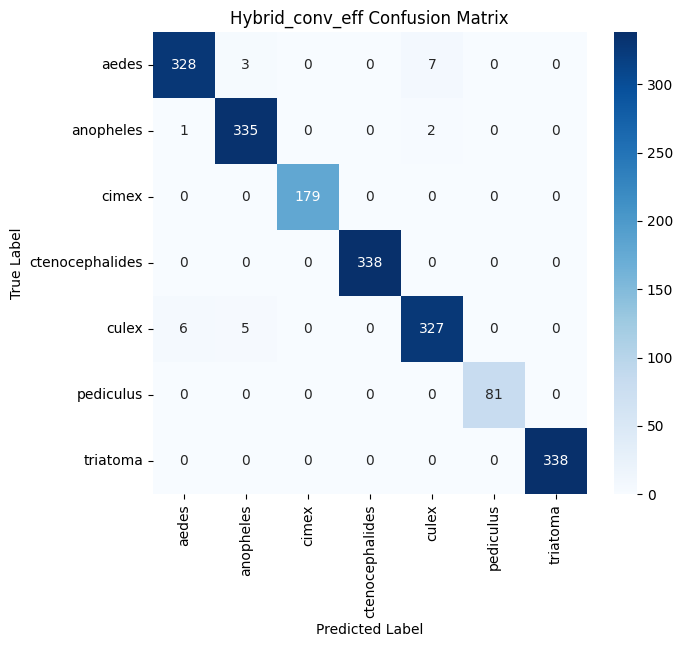

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hybrid_conv_eff Confusion Matrix")
plt.show()


In [ ]:
print("===== Hybrid_conv_eff Classification Report =====\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
))


===== Hybrid_conv_eff Classification Report =====

                 precision    recall  f1-score   support

          aedes     0.9791    0.9704    0.9747       338
      anopheles     0.9767    0.9911    0.9838       338
          cimex     1.0000    1.0000    1.0000       179
ctenocephalides     1.0000    1.0000    1.0000       338
          culex     0.9732    0.9675    0.9703       338
      pediculus     1.0000    1.0000    1.0000        81
       triatoma     1.0000    1.0000    1.0000       338

       accuracy                         0.9877      1950
      macro avg     0.9899    0.9899    0.9898      1950
   weighted avg     0.9877    0.9877    0.9877      1950



In [ ]:
from sklearn.preprocessing import label_binarize

num_classes = len(classes)

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        p1 = F.softmax(effnet(x), dim=1)
        p2 = F.softmax(convnext(x), dim=1)

        probs = 0.5 * p1 + 0.5 * p2

        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.hstack(all_labels)


y_true_bin = label_binarize(all_labels, classes=range(num_classes))


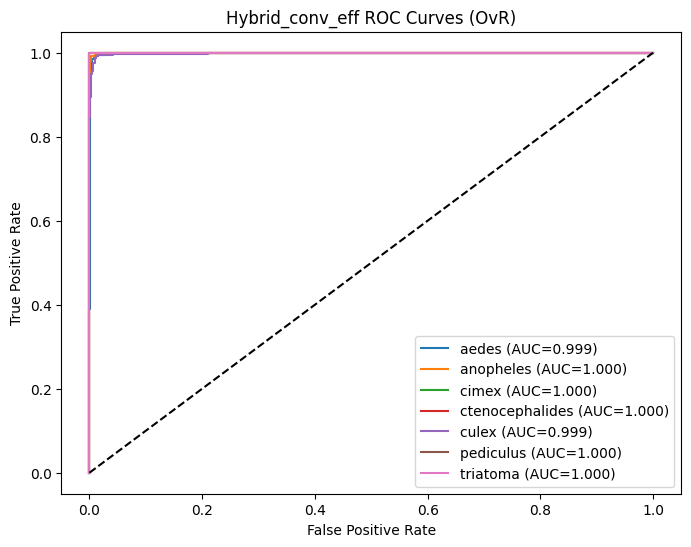

In [ ]:
plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Hybrid_conv_eff ROC Curves (OvR)")
plt.legend()
plt.show()


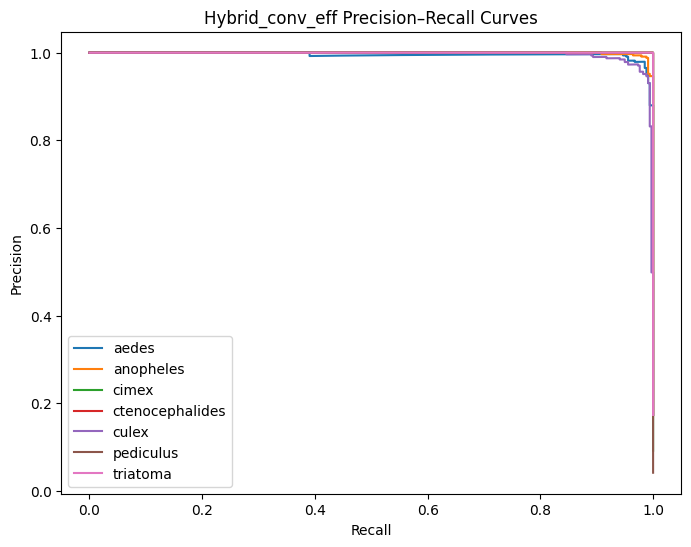

In [ ]:
plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        all_probs[:, i]
    )
    plt.plot(recall, precision, label=cls)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Hybrid_conv_eff Precision–Recall Curves")
plt.legend()
plt.show()


In [ ]:
np.save(
    "/content/drive/MyDrive/Insects/Results/hybrid_y_true.npy",
    y_true
)

np.save(
    "/content/drive/MyDrive/Insects/Results/hybrid_y_pred.npy",
    y_pred
)


In [ ]:
np.save(
    "/content/drive/MyDrive/Insects/Results/hybrid_probs.npy",
    all_probs
)


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

with open("/content/drive/MyDrive/Insects/Results/hybrid_report.txt", "w") as f:
    f.write("Hybrid Model: EfficientNet-B5 + ConvNeXt-Large\n")
    f.write("Alpha = 0.5\n")
    f.write("Test Accuracy = 0.9870\n\n")
    f.write(report)


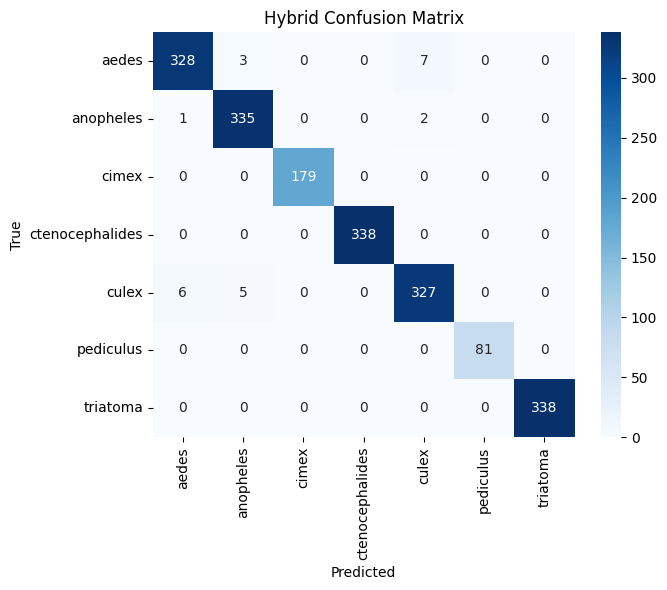

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Hybrid Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Insects/Results/hybrid_confusion_matrix.png",
    dpi=300
)
plt.show()


In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Insects/Results/hybrid_ROC.png",
    dpi=300
)

plt.savefig(
    "/content/drive/MyDrive/Insects/Results/hybrid_PR.png",
    dpi=300
)


<Figure size 640x480 with 0 Axes>